# does the archived noaa grid attach the right value to central park?

this check uses the primary june 1, 2025 forecast from the historical study: the retained may 31 bulletin with sha-256 `4f4887a39454f5bd09a21f41314dd802805cc25c2f563417aa6034b411738494`. message 2 was issued at 16:30z and is valid from june 1 12:00z through june 2 00:00z.

the notebook reads the existing private cache and makes no network request. one bulletin can verify decoder behavior and the saved study value. it cannot prove archive completeness, original receipt, or equivalence between the daytime forecast and the full settlement-day target.

In [1]:
import hashlib
import json
import math
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
from eccodes import codes_get_values, codes_grib_new_from_file, codes_release

from kalshi_information_quality_lab.ndfd import (
    GeographicCoordinate,
    GridCoordinate,
    NdfdDecodeError,
    extract_ndfd_max_temperature,
    find_ndfd_max_temperature_message,
)

repo = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "pyproject.toml").is_file()
)
plt.style.use(repo / "config/styles/custom_qb_dark_darien.mplstyle")
source = (
    repo
    / "outputs/historical-study/raw"
    / "7b84db4a743fb287b2ad6cc31fa6e04523500a7a06024e196af94394835e1c1a.body"
)
receipt = json.loads(source.with_suffix(".json").read_bytes())
source_sha256 = hashlib.sha256(source.read_bytes()).hexdigest()
assert source_sha256 == receipt["content_sha256"]
assert source_sha256 == "4f4887a39454f5bd09a21f41314dd802805cc25c2f563417aa6034b411738494"
print({"source_bytes": source.stat().st_size, "source_sha256": source_sha256})

{'source_bytes': 3142949, 'source_sha256': '4f4887a39454f5bd09a21f41314dd802805cc25c2f563417aa6034b411738494'}


## select the frozen message by its target interval

the bulletin contains several forecast intervals. the study selects the message whose encoded interval matches the required june 1 daytime window and whose issue time is no later than the prediction cutoff.

In [2]:
message_number = find_ndfd_max_temperature_message(
    source,
    valid_start_at=datetime(2025, 6, 1, 12, tzinfo=UTC),
    valid_end_at=datetime(2025, 6, 2, tzinfo=UTC),
    issued_by=datetime(2025, 5, 31, 16, 30, tzinfo=UTC),
)
assert message_number == 2
result = extract_ndfd_max_temperature(
    source,
    message_number=message_number,
    grid_coordinates=(
        GridCoordinate(row=859, column=1811),
        GridCoordinate(row=860, column=1811),
        GridCoordinate(row=861, column=1811),
        GridCoordinate(row=0, column=0),
    ),
    geographic_coordinates=(
        GeographicCoordinate(latitude=40.7789, longitude=-73.9692),
    ),
)
payload = result.to_dict()
print(
    {
        key: value
        for key, value in payload.items()
        if key not in {"points", "grid", "source_name"}
    }
)
print(payload["grid"])

{'schema_version': 'ndfd_max_temperature_extraction_v1', 'data_origin': 'public_noaa_source_sample', 'research_scope': 'decoder validation only; no Kalshi station/window mapping, historical coverage, availability time, or empirical forecast comparison', 'source_sha256': '4f4887a39454f5bd09a21f41314dd802805cc25c2f563417aa6034b411738494', 'message_number': 2, 'reference_at': '2025-05-31T16:30:00Z', 'valid_start_at': '2025-06-01T12:00:00Z', 'valid_end_at': '2025-06-02T00:00:00Z', 'forecast_start_hours': 19.5, 'interval_hours': 12, 'variable': 'maximum_temperature', 'source_units': 'K', 'height_above_ground_m': 2.0, 'missing_value': 9999.0, 'missing_count': 1479351}
{'rows': 1377, 'columns': 2145, 'point_count': 2953665, 'grid_type': 'lambert', 'grid_template': 30, 'scanning_mode': 80, 'alternative_row_scanning': True, 'i_scans_negatively': False, 'j_scans_positively': True}


## scan order matters on alternating rows

the grid uses scan mode 80, which alternates row direction. ecCodes returns canonical coordinates separately from the packed values, so a naive two-dimensional reshape mislabels odd rows. the paired coordinate/value iterator keeps each temperature attached to its location.

{'extraction_method': 'grid_coordinate', 'row': 859, 'column': 1811, 'latitude': 40.754168270872555, 'longitude': -73.9753066092594, 'source_longitude_degrees_east': 286.0246933907406, 'missing': False, 'temperature_k': 293.7, 'temperature_f': 68.99000000000002, 'requested_latitude': None, 'requested_longitude': None, 'distance_km': None}
{'extraction_method': 'grid_coordinate', 'row': 860, 'column': 1811, 'latitude': 40.77584402255292, 'longitude': -73.97083199294485, 'source_longitude_degrees_east': 286.02916800705515, 'missing': False, 'temperature_k': 293.7, 'temperature_f': 68.99000000000002, 'requested_latitude': None, 'requested_longitude': None, 'distance_km': None}
{'extraction_method': 'grid_coordinate', 'row': 861, 'column': 1811, 'latitude': 40.797517166825266, 'longitude': -73.96635548689852, 'source_longitude_degrees_east': 286.0336445131015, 'missing': False, 'temperature_k': 294.3, 'temperature_f': 70.07000000000006, 'requested_latitude': None, 'requested_longitude': No

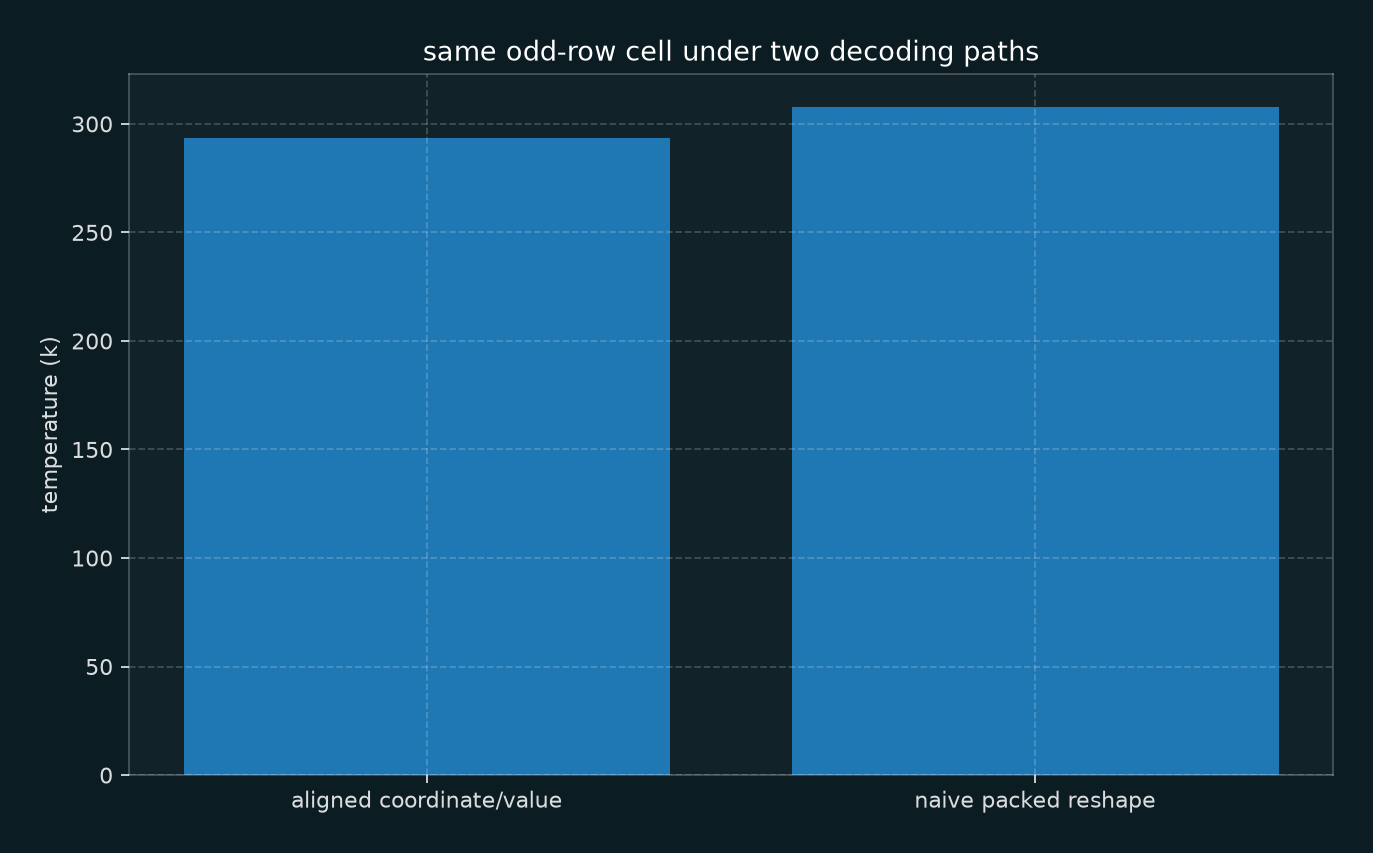

In [3]:
for point in payload["points"]:
    print(point)

previous, central_park, following, missing, nearest = result.points
assert (previous.row, previous.column, previous.temperature_k) == (859, 1811, 293.7)
assert (central_park.row, central_park.column, central_park.temperature_k) == (860, 1811, 293.7)
assert (following.row, following.column, following.temperature_k) == (861, 1811, 294.3)
assert missing.missing and missing.temperature_k is None and missing.temperature_f is None

handle = None
try:
    with source.open("rb") as stream:
        for _ in range(message_number):
            if handle is not None:
                codes_release(handle)
            handle = codes_grib_new_from_file(stream)
    assert handle is not None
    values = codes_get_values(handle).reshape(result.grid.rows, result.grid.columns)
    naive = float(values[859, 1811])
finally:
    if handle is not None:
        codes_release(handle)

assert math.isclose(previous.temperature_k, 293.7)
assert math.isclose(naive, 307.6)
assert not math.isclose(previous.temperature_k, naive)
plt.bar(["aligned coordinate/value", "naive packed reshape"], [previous.temperature_k, naive])
plt.ylabel("temperature (k)")
plt.title("same odd-row cell under two decoding paths")
plt.tight_layout(pad=1.5)
plt.show()

## match the saved central park forecast

the nearest-cell lookup recovers row 860, column 1811 and the 68.99°F value saved in the primary historical panel.

In [4]:
assert (nearest.row, nearest.column) == (860, 1811)
assert nearest.distance_km is not None and nearest.distance_km < .4
assert nearest.temperature_k == 293.7
assert math.isclose(nearest.temperature_f, 68.99, abs_tol=1e-12)
assert result.reference_at.isoformat() == "2025-05-31T16:30:00+00:00"
assert result.valid_start_at.isoformat() == "2025-06-01T12:00:00+00:00"
assert result.valid_end_at.isoformat() == "2025-06-02T00:00:00+00:00"

panel = json.loads((repo / "outputs/historical-study/panel.json").read_bytes())
saved_case = next(
    row
    for row in panel["cases"]
    if row["outcome_date"] == "2025-06-01" and row["horizon_hours"] == 12
)
saved_forecast = saved_case["forecast"]
assert saved_forecast["source_sha256"] == source_sha256
assert saved_forecast["message_number"] == message_number
assert (saved_forecast["grid_row"], saved_forecast["grid_column"]) == (860, 1811)
assert math.isclose(saved_forecast["forecast_f"], nearest.temperature_f, abs_tol=1e-12)
print(
    {
        "case_id": saved_case["case_id"],
        "grid_cell": (nearest.row, nearest.column),
        "distance_km": nearest.distance_km,
        "forecast_f": nearest.temperature_f,
    }
)

{'case_id': 'KXHIGHNY-25JUN01-12h', 'grid_cell': (860, 1811), 'distance_km': 0.3665548851681874, 'forecast_f': 68.99000000000002}


## fail closed on an invalid request

an out-of-bounds cell is rejected instead of clipped to the grid edge.

In [5]:
try:
    extract_ndfd_max_temperature(
        source,
        message_number=message_number,
        grid_coordinates=(GridCoordinate(row=1377, column=0),),
    )
except NdfdDecodeError as error:
    print("rejected invalid coordinate:", error)
else:
    raise AssertionError("out-of-bounds row was accepted")

rejected invalid coordinate: grid coordinate (1377, 0) is outside 1377x2145


## result

the retained bulletin, decoded message interval, central park grid cell, and temperature all match the empirical panel. the scan-order comparison shows why coordinate/value pairing is required. the study still treats NDFD MaxT as a daytime predictor rather than the settlement target itself.